========== Model Evaluation ==========
Mean Absolute Error (MAE): 2.45
Mean Squared Error (MSE): 10.86
R2 Score: 0.23

First 10 Predictions
   Actual Score  Predicted Score
0            65            67.22
1            65            67.80
2            71            67.51
3            64            64.94
4            66            67.51
5            66            67.51
6            72            72.08
7            66            68.37
8            70            66.37
9            70            66.08


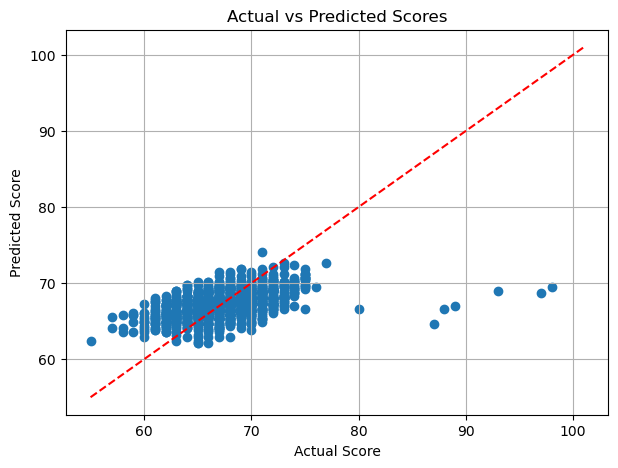

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
df = pd.read_csv("StudentPerformanceFactors.csv")

# Select Feature and Target
X = df[['Hours_Studied']]
y = df['Exam_Score']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict Test Data
y_pred = model.predict(X_test)

# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("========== Model Evaluation ==========")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

# Comparison Table
comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": y_pred.round(2)
})

print("\nFirst 10 Predictions")
print(comparison.head(10))

# Scatter Plot
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")
plt.grid(True)

plt.show()